In [1]:
import os
import shutil
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import flopy

In [2]:
import struct
import re


In [61]:
def read_modflow96_heads(filename):
    heads = []
    with open(filename, 'rb') as f:
        while True:
            header = f.read(48)  # full header
            if len(header) < 48:
                break
            kstp, kper, itype = struct.unpack('iii', header[:12])
            pertim, totim = struct.unpack('ff', header[12:20])
            text = header[20:36].decode('utf-8', errors='replace').strip()
            ncol, nrow, ilay = struct.unpack('iii', header[36:48])

            nval = nrow * ncol
            data = f.read(4 * nval)
            if len(data) < 4 * nval:
                break
            head = np.frombuffer(data, dtype=np.float32).reshape((nrow, ncol))
            heads.append({
                'kstp': kstp,
                'kper': kper,
                'pertim': pertim,
                'totim': totim,
                'ilay': ilay,
                'label': text,
                'head': head
            })
    return heads
def debug_modflow96_headers(filename, max_records=5):
    with open(filename, 'rb') as f:
        i = 0
        while i < max_records:
            header = f.read(48)
            if len(header) < 48:
                print("Reached end of file.")
                break
            kstp, kper, itype = struct.unpack('iii', header[:12])
            pertim, totim = struct.unpack('ff', header[12:20])
            text = header[20:36].decode('utf-8', errors='replace').strip()
            ncol, nrow, ilay = struct.unpack('iii', header[36:48])

            print(f"Record {i}:")
            print(f"  KSTP: {kstp}, KPER: {kper}, ITYPE: {itype}")
            print(f"  PERTIM: {pertim}, TOTIM: {totim}")
            print(f"  Label: {text}")
            print(f"  NCOL: {ncol}, NROW: {nrow}, ILAY: {ilay}")
            print(f"  Data size to read: {4 * ncol * nrow / 1024:.2f} KB")

            # Skip actual data read to avoid memory issues
            f.seek(4 * ncol * nrow, 1)  # move forward

            i += 1

def scan_head_file_for_labels(filename, max_hits=5):
    with open(filename, 'rb') as f:
        data = f.read()
    hits = 0
    i = 0
    while i < len(data) - 20:
        if data[i:i+4] == b'HEAD':
            print(f"Found 'HEAD' at byte offset: {i}")
            following = data[i+4:i+16]
            print("Next 12 bytes after 'HEAD':", following.hex())
            hits += 1
            if hits >= max_hits:
                break
        i += 1

def read_custom_head_file(filename, expected_layers=12):
    records = []
    with open(filename, 'rb') as f:
        while True:
            header = f.read(16)  # 4 ('HEAD') + 3 ints
            if len(header) < 16:
                break
            if header[:4] != b'HEAD':
                break

            ncol = int.from_bytes(header[4:8], byteorder='little')
            nrow = int.from_bytes(header[8:12], byteorder='little')
            ilay = int.from_bytes(header[12:16], byteorder='little')

            arr_bytes = nrow * ncol * 4
            data = f.read(arr_bytes)
            if len(data) < arr_bytes:
                break

            head = np.frombuffer(data, dtype=np.float32).reshape((nrow, ncol))
            records.append((ilay, head))

            if len(records) >= expected_layers:
                break

    # Sort by layer number
    records.sort(key=lambda x: x[0])
    heads = np.array([r[1] for r in records])
    return heads  # shape: (nlay, nrow, ncol)

def read_ibound_from_binary_bas(file_path, nlay, nrow, ncol):
    ibound_arrays = []

    with open(file_path, 'rb') as f:
        while True:
            header = f.read(4 * 5 + 16)  # 5 integers + 16-char label
            if not header:
                break  # EOF

            # Unpack: KSTP, KPER, TEXT (16s), NCOL, NROW, ILAY
            kstp, kper, text, ncol_, nrow_, ilay = struct.unpack('ii16siii', header)
            text = text.decode('ascii').strip()

            # Sanity check
            if ncol_ != ncol or nrow_ != nrow:
                raise ValueError("Grid dimensions mismatch")

            # Read array
            arr = np.fromfile(f, dtype=np.float32, count=nrow * ncol).reshape((nrow, ncol))

            if text.upper().startswith('IBOUND'):
                print(f'Found IBOUND for layer {ilay}')
                ibound_arrays.append(arr.astype(int))

            if len(ibound_arrays) == nlay:
                break

    return np.array(ibound_arrays)

def read_ibound_fortran_unformatted(file_path, nlay, nrow, ncol):
    ibound_arrays = []
    expected_size = nrow * ncol * 4  # float32 = 4 bytes

    with open(file_path, 'rb') as f:
        for ilay in range(nlay):
            # Read record length header
            rec_len_start = struct.unpack('i', f.read(4))[0]
            if rec_len_start != expected_size:
                raise ValueError(f"Unexpected record size at layer {ilay + 1}: got {rec_len_start}, expected {expected_size}")
            
            # Read array data
            arr_flat = np.fromfile(f, dtype=np.float32, count=nrow * ncol)
            arr = arr_flat.reshape((nrow, ncol))
            ibound_arrays.append(arr.astype(int))

            # Read record length footer
            rec_len_end = struct.unpack('i', f.read(4))[0]
            if rec_len_end != rec_len_start:
                raise ValueError(f"Record length mismatch at layer {ilay + 1}")

    return np.array(ibound_arrays)


def read_fixed_width_ascii_ibound(file_path, nlay, nrow, ncol):
    values = []
    with open(file_path, 'r', errors='ignore') as f:
        for line in f:
            # Remove nulls or weird padding, then split
            clean_line = line.strip().replace('\x00', '')
            if clean_line:
                parts = clean_line.split()
                values.extend([int(float(p)) for p in parts])  # Some may be written as floats

    expected = nlay * nrow * ncol
    if len(values) != expected:
        raise ValueError(f"Expected {expected} values, got {len(values)}")

    return np.array(values).reshape((nlay, nrow, ncol))

def read_numeric_arrays_from_bas(file_path, nlay, nrow, ncol, keyword="IBOUND"):
    values = []
    parsing = False

    with open(file_path, 'r', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if keyword in line.upper():
                parsing = True
                continue

            if parsing:
                parts = line.split()
                for p in parts:
                    try:
                        values.append(int(float(p)))
                    except ValueError:
                        continue  # Skip things like "FREE", "CONSTANT", etc.

                if len(values) >= nlay * nrow * ncol:
                    break

    if len(values) != nlay * nrow * ncol:
        raise ValueError(f"Expected {nlay*nrow*ncol} values, got {len(values)}")

    arr = np.array(values).reshape((nlay, nrow, ncol))
    return arr

def read_strthd_from_bas(file_path, nlay, nrow, ncol):
    values = []
    parsing = False

    with open(file_path, 'r', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if "HEAD" in line.upper():
                parsing = True
                continue

            if parsing:
                parts = line.split()
                for p in parts:
                    try:
                        values.append(float(p))
                    except ValueError:
                        continue  # Skip "INTERNAL", "FREE", etc.

                if len(values) >= nlay * nrow * ncol:
                    break

    if len(values) != nlay * nrow * ncol:
        raise ValueError(f"Expected {nlay*nrow*ncol} values, got {len(values)}")

    arr = np.array(values).reshape((nlay, nrow, ncol))
    return arr

def parse_bas_ibound(basfile, nlay, nrow, ncol):
    ibound = np.zeros((nlay, nrow, ncol), dtype=int)
    with open(basfile, 'r') as f:
        lines = f.readlines()

    layer = -1
    row = 0
    mode = None  # 'fixed', 'free', 'constant'

    for line in lines:
        line_strip = line.strip()
        if "IBOUND" in line_strip:
            # Identify layer number
            m = re.search(r"LAYERS? (\d+)", line_strip)
            if m:
                layer = int(m.group(1)) - 1
                row = 0

            # Identify data format
            if "(FREE)" in line_strip:
                mode = 'free'
            elif "(15I3)" in line_strip:
                mode = 'fixed'
            elif "CONSTANT" in line_strip:
                mode = 'constant'
                # Extract constant value
                m2 = re.search(r"CONSTANT\s+(-?\d+)", line_strip)
                if m2:
                    const_val = int(m2.group(1))
                    ibound[layer, :, :] = const_val
                    # no further reading for this layer
                    layer = -1
            else:
                mode = None
            continue

        if layer >= 0 and mode == 'fixed' and row < nrow:
            # Fixed width: 15 integers each 3 chars wide
            row_vals = [int(line[i:i+3]) for i in range(0, 15*3, 3)]
            ibound[layer, row, :len(row_vals)] = row_vals
            row += 1

        elif layer >= 0 and mode == 'free' and row < nrow:
            # Free format: split by whitespace
            vals = list(map(int, line_strip.split()))
            ibound[layer, row, :len(vals)] = vals
            row += 1

    return ibound

In [4]:
# heads = read_custom_head_file(os.path.join('..', 'data', "heads.dat"))
# scan_head_file_for_labels(os.path.join('..', 'data', "heads.dat"))

# model = flopy.modflow.Modflow.load(os.path.join("..", "..", "dizon", "data", "dizon36_final_est_raw",
#                                                 "dizon.nam"), version='mf96', verbose=True)
basfile = os.path.join("..", "..", "dizon", "data", "dizon36_final_est_raw",
                                                "BAS.DAT")
read_numeric_arrays_from_bas(basfile,nlay=12, nrow=10, ncol=51)
ibound = parse_bas_ibound(basfile, nlay=3, nrow=15, ncol=15)

print("IBOUND array shape:", ibound.shape)
print("Sample IBOUND layer 1 row 0:", ibound[0,0,:])
# print(f"Found {len(heads)} records")
# for rec in heads[:2]:  # preview first two records
#     print(f"KPER: {rec['kper']}, KSTP: {rec['kstp']}, ILAY: {rec['ilay']}")
#     print(rec['head'])

IBOUND array shape: (3, 15, 15)
Sample IBOUND layer 1 row 0: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [5]:
ibound

array([[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        

In [6]:
import struct

with open(basfile, "rb") as f:
    first_bytes = f.read(100)
    print("First 100 bytes:", first_bytes)
    try:
        ints = struct.unpack('5i', first_bytes[:20])
        print("Interpreted as 5 ints:", ints)
        label = struct.unpack('16s', first_bytes[8:24])[0].decode('ascii').strip()
        print("Possible label:", label)
    except Exception as e:
        print("Failed to parse as header:", e)



First 100 bytes: b'\x00                                                                               \r\n                  '
Interpreted as 5 ints: (538976256, 538976288, 538976288, 538976288, 538976288)
Possible label: 


In [7]:
with open(basfile, "rb") as f:
    text = f.read(500).decode('ascii', errors='ignore')
    print(text)

                                                                                
                                                                                                                                                                                                                                                                                                                                                                                                                                  


In [8]:
import flopy.utils.binaryfile as bf

# Replace with your path to head.dat
# headfile = bf.HeadFile(os.path.join('..', 'data', "heads.dat"), text='heads', precision="single", verbose=True)

# with open(os.path.join('..', 'data', "heads.dat"), "rb") as f:
#     print(f.read(64))

In [32]:
cwd = os.getcwd()
dis_ws = os.path.join(cwd, 'dis')
props_ws = os.path.join(cwd, 'props')

model_ws = os.path.join(os.getcwd(), 'model')
if not os.path.exists(model_ws):
    os.makedirs(model_ws)
    

In [33]:
cwd

'c:\\Users\\portega\\intera\\dev\\dizon36\\mf6-gw'

In [34]:
# define mf6 exectuable path
mf6_exe_ws = os.path.join(cwd, 'bin', 'win', 'mf6.exe')  # Path to the executable
# define the full path for the destination file
mf6_exe_ws_model = os.path.join(model_ws, 'mf6.exe')
# copy the executable file to the new folder
shutil.copy(mf6_exe_ws, mf6_exe_ws_model)

'c:\\Users\\portega\\intera\\dev\\dizon36\\mf6-gw\\model\\mf6.exe'

In [35]:
def reformat_arrays(input_file, output_file, rows, cols):
    # Read the content of the file
    with open(input_file, 'r') as f:
        content = f.read()

    # Flatten the values into a 1D array and remove spaces or NaNs
    values = [val for val in content.split() if val.strip() and val.lower() != 'nan']

    # Convert values to a numpy array
    values_array = np.array(values)

    # Ensure the array can be reshaped to the desired shape
    if len(values_array) != rows * cols:
        raise ValueError("The number of values does not match the specified shape")

    # Reshape the array into the specified shape
    reshaped_array = values_array.reshape((rows, cols))

    # Save the reshaped array to a new file with _format extension
    np.savetxt(output_file, reshaped_array, fmt='%s')
    
    # return reshaped array
    return reshaped_array

In [36]:
def calculate_vertical_conductivity(vcont, thickness, nlay, nrow, ncol):
    nlay, nrow, ncol = vcont.shape
    k33 = np.zeros((nlay, nrow, ncol))

    for i in range(nlay - 1):
        for j in range(nrow):
            for k in range(ncol):
                k33[i, j, k] = vcont[i, j, k] * ((thickness[i, j, k] / 2) + (thickness[i + 1, j, k] / 2))
    # Set the vertical hydraulic conductivity of layer 12 equal to layer 11
    k33[-1] = k33[-2]
    
    return k33

In [37]:
# create flow model
model_name = 'dizon-mf6rtm'

# Define model parameters for the dummy model
nlay = 12  # Number of layers
nrow = 10  # Number of rows
ncol = 51  # Number of columns
nper = 39  # Number of stress periods
delc = [4, 40, 24, 16, 12,
        10, 6, 4, 4, 4]  # Column spacing (meters)
delr = [4, 16, 8, 4, 4, 4, 4, 3, 2, 2, 
        2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        3, 3, 3, 2, 2, 2, 2, 2, 2, 2,
        3, 4, 4, 4, 4, 4, 4, 12, 24, 40, 
        4]  # Column Spacing (meters)

perioddata= [(2, 2, 1), (4, 4, 1), (4, 4, 1), (4, 4, 1), (7, 7, 1),
             (7, 7, 1), (7, 7, 1), (7, 7, 1), (14, 14, 1), (14, 14, 1), 
             (15, 15, 1), (13, 13, 1), (14, 14, 1), (14, 14, 1), (14, 14, 1), 
             (21, 21, 1), (35, 35, 1), (28, 28, 1), (28, 28, 1), (28, 28, 1), 
             (28, 28, 1), (28, 28, 1), (28, 28, 1), (28, 28, 1), (28, 28, 1), 
             (35, 35, 1), (35, 35, 1), (28, 28, 1), (28, 28, 1), (28, 28, 1), 
             (35, 35, 1), (35, 35, 1), (28, 28, 1), (28, 28, 1), (28, 28, 1), 
             (28, 28, 1), (35, 35, 1), (35, 35, 1),(28, 28, 1)]

In [38]:
top = -273  # Top elevation (constant, meters above mean sea level)
#botm = np.linspace(40, -10, nlay)
botm = np.zeros((nlay, nrow, ncol))  # Bottom elevations of each layer (meters)
steady = [False] * nper  # All stress periods are transient

# specify the mf6 gw object & add relevant components
flow_model = flopy.mf6.MFSimulation(sim_name=model_name, version='mf6', sim_ws='.')
flow_model.set_sim_path(model_ws)

# specify tdis
tdis = flopy.mf6.ModflowTdis(flow_model, pname="tdis", time_units="DAYS", nper=nper, perioddata=perioddata)

# specify ims pkg 
ims = flopy.mf6.ModflowIms(flow_model, pname="ims", complexity="SIMPLE")

# start model build to refine 
model_nam_file = "{}.nam".format(model_name)
gwf = flopy.mf6.ModflowGwf(flow_model, modelname=model_name, model_nam_file=model_nam_file, exe_name=mf6_exe_ws_model)

# specify dis pkg
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
)

In [39]:
# specify the initial conditions
ihead = 0 #(meters)
start = ihead * np.ones((nlay, nrow, ncol))
ic = flopy.mf6.ModflowGwfic(gwf, pname="ic", strt=start)

In [40]:
# now let's start filling data from the mf96 arrays to populate the mf6 model
layer_txt_files = ['layer_1.txt', 'layer_2.txt', 'layer_3.txt', 'layer_4.txt', 
                   'layer_5.txt', 'layer_6.txt', 'layer_7.txt', 'layer_8.txt', 
                   'layer_9.txt', 'layer_10.txt', 'layer_11.txt', 'layer_12.txt']

# first load in mf96 top elev array reformt and assign to mf6 dis
top_elev = reformat_arrays(os.path.join(dis_ws, 'tops', 'top_elev.txt'), 
                           os.path.join(dis_ws, 'tops', 'format_top_elev.txt'), 
                           nrow, 
                           ncol)
dis.top = top_elev # meters above mean sea level

# now let's load in the mf96 bottom elevations

botm96 = np.zeros((nlay, nrow, ncol))
ibnd96 = np.ones((nlay, nrow, ncol))
thick96 = np.zeros((nlay, nrow, ncol))
scoeff96 = np.zeros((nlay, nrow, ncol))
trans96 = np.zeros((nlay, nrow, ncol))
k = np.zeros((nlay, nrow, ncol))
k33 = np.zeros((nlay, nrow, ncol))
vcont96 = np.zeros((nlay, nrow, ncol))

for i, layer_txt_files in enumerate(layer_txt_files):
    botm96[i] = reformat_arrays(os.path.join(dis_ws, 'bottoms', layer_txt_files), 
                                os.path.join(dis_ws, 'bottoms', 'format_'+str(layer_txt_files)), 
                                nrow, 
                                ncol)
    # ibnd96[i] = reformat_arrays(os.path.join(dis_ws, 'ibound', layer_txt_files), 
    #                             os.path.join(dis_ws, 'ibound', 'format_'+str(layer_txt_files)), 
    #                             nrow, 
    #                             ncol)
    thick96[i] = reformat_arrays(os.path.join(dis_ws, 'thicknesses', layer_txt_files), 
                                os.path.join(dis_ws, 'thicknesses', 'format_'+str(layer_txt_files)), 
                                nrow, 
                                ncol)
    scoeff96[i] = reformat_arrays(os.path.join(props_ws, 'S', layer_txt_files), 
                                os.path.join(props_ws, 'S', 'format_'+str(layer_txt_files)), 
                                nrow, 
                                ncol)
    trans96[i] = reformat_arrays(os.path.join(props_ws, 'T', layer_txt_files), 
                                os.path.join(props_ws, 'T', 'format_'+str(layer_txt_files)), 
                                nrow, 
                                ncol)
    vcont96[i] = reformat_arrays(os.path.join(props_ws, 'vcont', layer_txt_files), 
                                os.path.join(props_ws, 'vcont', 'format_'+str(layer_txt_files)), 
                                nrow, 
                                ncol)
    
dis.botm = botm96 # meters above mean sea level
dis.idomain = ibnd96
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=0,
    k=k,
    k33=k33,
)
npf.k = trans96/thick96
  
# Calculate vertical hydraulic conductivity from vcont
k33_array = calculate_vertical_conductivity(vcont96, thick96, nlay, nrow, ncol)
k33 = flopy.mf6.ModflowGwfnpf(gwf, k33=k33_array)

# Create the sto package with specific storage and specific yield
sto = flopy.mf6.ModflowGwfsto(gwf, ss=scoeff96/thick96, iconvert=0)

In [41]:
ibnd96

array([[[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]],

       ...,

       [[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1.

In [42]:
ib=dis.idomain.get_data()
ib
l_hd= 0
# chdspd_l = [[(i, 0, 0), l_hd] for i in range(nlay)]
# chdspd_r = [[(i, 0, ncol - 1), l_hd] for i in range(nlay)]
# chdspd_r.extend(chdspd_l)
chdspd = []

for i in range(nlay):          # layers
    for j in range(nrow):      # rows
        chdspd.append([(i, j, 0), l_hd])           # left boundary
        chdspd.append([(i, j, ncol - 1), l_hd])    # right boundary

chd = flopy.mf6.ModflowGwfchd(
    gwf,
    maxbound=len(chdspd),
    stress_period_data=chdspd,
    save_flows=True,
    pname="CHD",
    filename=f"{model_name}.chd",
)
chd.write()

In [43]:
# Define wel package injection & extraction wells & schedules
flopy_offset = 1
pumping_data_init = [[2-flopy_offset, 10-flopy_offset, 10-flopy_offset, -300],
                     [2-flopy_offset, 10-flopy_offset, 39-flopy_offset, 117.5],
                     [3-flopy_offset, 10-flopy_offset, 39-flopy_offset, 40],
                     [4-flopy_offset, 10-flopy_offset, 10-flopy_offset, -30],
                     [4-flopy_offset, 10-flopy_offset, 39-flopy_offset, 70],
                     [6-flopy_offset, 10-flopy_offset, 10-flopy_offset, -30],
                     [6-flopy_offset, 10-flopy_offset, 39-flopy_offset, 95],
                     [8-flopy_offset, 10-flopy_offset, 39-flopy_offset, 37.5]]

pumping_data_fini = [[2-flopy_offset, 10-flopy_offset, 10-flopy_offset, -400],
                     [2-flopy_offset, 10-flopy_offset, 39-flopy_offset, 156.7],
                     [3-flopy_offset, 10-flopy_offset, 39-flopy_offset, 53.3],
                     [4-flopy_offset, 10-flopy_offset, 10-flopy_offset, -40],
                     [4-flopy_offset, 10-flopy_offset, 39-flopy_offset, 93.3],
                     [6-flopy_offset, 10-flopy_offset, 10-flopy_offset, -40],
                     [6-flopy_offset, 10-flopy_offset, 39-flopy_offset, 126.6],
                     [8-flopy_offset, 10-flopy_offset, 39-flopy_offset, 50]]

stress_period_data = {0: pumping_data_init, 1: pumping_data_init, 2: pumping_data_init,
                      3: pumping_data_init, 4: pumping_data_init, 5: pumping_data_init,
                      6: pumping_data_init, 7: pumping_data_init, 8: pumping_data_init,
                      9: pumping_data_init, 10: pumping_data_init, 11: pumping_data_init,
                      12: pumping_data_init, 13: pumping_data_init, 14: pumping_data_init,
                      15: pumping_data_init, 16: pumping_data_init, 17: pumping_data_init,
                      18: pumping_data_init, 19: pumping_data_init, 20: pumping_data_init,
                      21: pumping_data_init, 22: pumping_data_init, 23: pumping_data_init,
                      24: pumping_data_init, 25: pumping_data_init, 26: pumping_data_init,
                      27: pumping_data_init, 28: pumping_data_init, 29: pumping_data_init,
                      30: pumping_data_init, 31: pumping_data_init, 32: pumping_data_init,
                      33: pumping_data_init,  34: pumping_data_init, 35: pumping_data_init,
                      36: pumping_data_fini, 37: pumping_data_fini, 38: pumping_data_fini}

wel = flopy.mf6.ModflowGwfwel(gwf,stress_period_data=stress_period_data, filename='dizon-mf6rtm.wel')


In [113]:
stress_period_data

{0: [[1, 9, 9, -300],
  [1, 9, 38, 117.5],
  [2, 9, 38, 40],
  [3, 9, 9, -30],
  [3, 9, 38, 70],
  [5, 9, 9, -30],
  [5, 9, 38, 95],
  [7, 9, 38, 37.5]],
 1: [[1, 9, 9, -300],
  [1, 9, 38, 117.5],
  [2, 9, 38, 40],
  [3, 9, 9, -30],
  [3, 9, 38, 70],
  [5, 9, 9, -30],
  [5, 9, 38, 95],
  [7, 9, 38, 37.5]],
 2: [[1, 9, 9, -300],
  [1, 9, 38, 117.5],
  [2, 9, 38, 40],
  [3, 9, 9, -30],
  [3, 9, 38, 70],
  [5, 9, 9, -30],
  [5, 9, 38, 95],
  [7, 9, 38, 37.5]],
 3: [[1, 9, 9, -300],
  [1, 9, 38, 117.5],
  [2, 9, 38, 40],
  [3, 9, 9, -30],
  [3, 9, 38, 70],
  [5, 9, 9, -30],
  [5, 9, 38, 95],
  [7, 9, 38, 37.5]],
 4: [[1, 9, 9, -300],
  [1, 9, 38, 117.5],
  [2, 9, 38, 40],
  [3, 9, 9, -30],
  [3, 9, 38, 70],
  [5, 9, 9, -30],
  [5, 9, 38, 95],
  [7, 9, 38, 37.5]],
 5: [[1, 9, 9, -300],
  [1, 9, 38, 117.5],
  [2, 9, 38, 40],
  [3, 9, 9, -30],
  [3, 9, 38, 70],
  [5, 9, 9, -30],
  [5, 9, 38, 95],
  [7, 9, 38, 37.5]],
 6: [[1, 9, 9, -300],
  [1, 9, 38, 117.5],
  [2, 9, 38, 40],
  [3, 9, 9, -30

In [44]:
dis.idomain.export(os.path.join(f"{model_name}.vtk"), fmt="vtk")
wel.export(os.path.join(f"{model_name}.vtk"), fmt="vtk")
npf.k.export(os.path.join(f"{model_name}.vtk"), fmt="vtk")
chd.export(os.path.join(f"{model_name}.vtk"), fmt="vtk")

In [22]:
# create the output control
headfile = f"{model_name}.hds"
head_filerecord = [headfile]
budgetfile = f"{model_name}.cbb"
budget_filerecord = [budgetfile]
saverecord = [("HEAD", "ALL"), ("BUDGET", "ALL")]
printrecord = [("HEAD", "LAST")]
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    saverecord=saverecord,
    head_filerecord=head_filerecord,
    budget_filerecord=budget_filerecord,
    printrecord=printrecord,)

In [45]:
# write the mf6 flow model input files
flow_model.write_simulation()


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model dizon-mf6rtm...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package chd...
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 8 based on size of stress_period_data


In [24]:

# Run the mf6 flow simulation
os.chdir(model_ws)
# Run the executable from the destination folder
result = subprocess.run(['mf6.exe'], check=True, capture_output=True, text=True)

# Capture standard output and error messages from the executable
print("Simulation Output:")
print(result.stdout)

# Check if the simulation ran successfully
if result.returncode == 0:
    print("Simulation ran successfully!")
else:
    print(f"Simulation failed with error code {result.returncode}.")
    print(result.stderr)
    
os.chdir(cwd)

Simulation Output:
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                   VERSION 6.3.0 release candidate 02/06/2022
                               ***DEVELOP MODE***

   MODFLOW 6 compiled Feb 06 2022 02:35:51 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.5.0
                             Build 20211109_000000

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages re

In [46]:
# Get the time discretization information
tdis = gwf.simulation.tdis
perioddata = tdis.perioddata.array

# Calculate cumulative end times from each stress period
cumulative_time = 0
end_of_stress_period_times = []
for perlen in perioddata["perlen"]:
    cumulative_time += perlen
    end_of_stress_period_times.append(cumulative_time)

In [47]:
gwf

name = dizon-mf6rtm
model_type = gwf6
version = mf6
model_relative_path = .

###################
Package dis
###################

package_name = dis
filename = dizon-mf6rtm.dis
package_type = dis
model_or_simulation_package = model
model_name = dizon-mf6rtm


###################
Package ic
###################

package_name = ic
filename = dizon-mf6rtm.ic
package_type = ic
model_or_simulation_package = model
model_name = dizon-mf6rtm


###################
Package npf
###################

package_name = npf
filename = dizon-mf6rtm.npf
package_type = npf
model_or_simulation_package = model
model_name = dizon-mf6rtm


###################
Package sto
###################

package_name = sto
filename = dizon-mf6rtm.sto
package_type = sto
model_or_simulation_package = model
model_name = dizon-mf6rtm


###################
Package chd
###################

package_name = chd
filename = dizon-mf6rtm.chd
package_type = chd
model_or_simulation_package = model
model_name = dizon-mf6rtm


############

C:\Users\portega\AppData\Local\Temp\ipykernel_10916\3550047970.py:23: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)  # Leave space for the colorbar


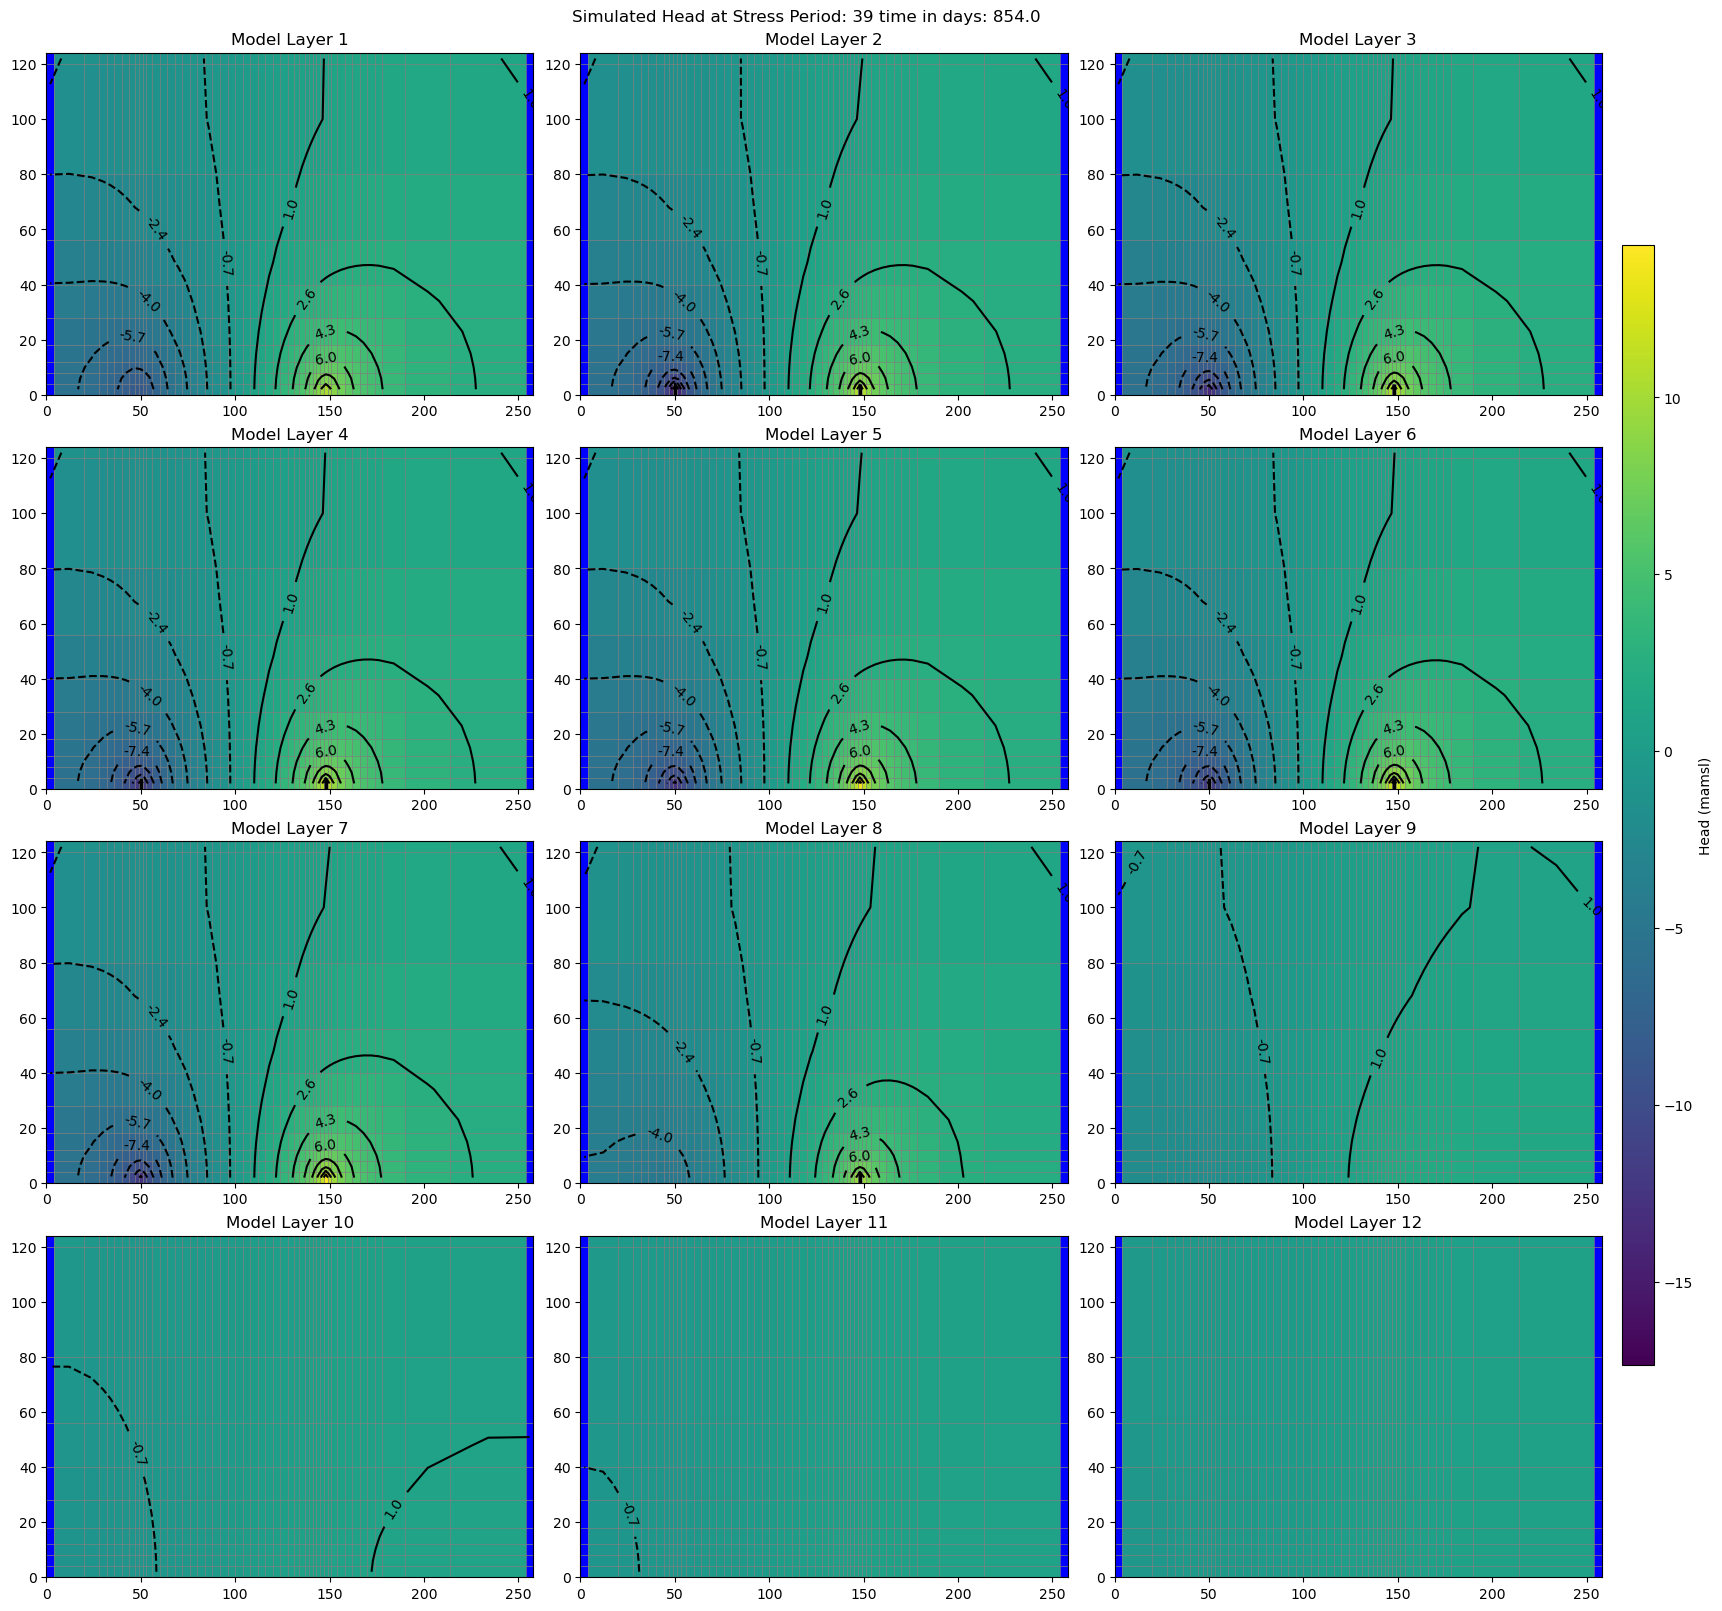

In [52]:
# plot heads in mapview for each layer
h = gwf.output.head().get_alldata()

# plot the head results mapview
mapview_output_dir = os.path.join(model_ws, 'output', 'mapview')
if not os.path.exists(mapview_output_dir):
    os.makedirs(mapview_output_dir)

mapview_counter = 0
for t in range(nper-1, nper):
    h_t = h[t, :, :, :]
    masked_h = np.ma.masked_where((h_t < -500) | (h_t > 500), h_t)
    vmin = masked_h.min()
    vmax = masked_h.max()
    vmin, vmax = np.nanmin(masked_h), np.nanmax(masked_h)  # Set colorbar limits

    contour_intervals = np.linspace(vmin, vmax, 20)  # Contour levels

    #contour_intervals = np.arange(vmin, vmax, (vmax-vmin)/10)
    
    # Create a figure with 4 rows and 3 columns
    fig, axes = plt.subplots(4, 3, figsize=(16, 16), constrained_layout=True)
    fig.subplots_adjust(right=0.85)  # Leave space for the colorbar
    
    # Loop over all layers
    for i, ax in enumerate(axes.flat):
        if i < nlay:
            # Plot for layer `i`
            ax.set_title(f"Model Layer {i + 1}")
            modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=i)
    
            # Plot array, boundary conditions, and contours
            pa = modelmap.plot_array(masked_h[i, :, :], vmin=vmin, vmax=vmax)
            modelmap.plot_bc("WEL", color='black')
            modelmap.plot_bc("CHD", color='blue')
            modelmap.plot_grid(lw=0.5, color="0.5")
            contours = modelmap.contour_array(
                masked_h[i, :, :],
                levels=contour_intervals,
                colors="black",
            )
            ax.clabel(contours, fmt="%2.1f")
        else:
            # Hide axes for extra subplots
            ax.axis("off")
    
    # Add a single colorbar for the entire figure
    cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(pa, cax=cbar_ax, label="Head (mamsl)")
    plt.suptitle('Simulated Head at Stress Period: ' + str(t+1) + ' time in days: ' + str(end_of_stress_period_times[t]))
    # Use tight_layout for clean subplot spacing
    #fig.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to leave space for the colorbar
    fig.savefig(os.path.join(os.getcwd(), mapview_output_dir, '000' + str(mapview_counter) + '_SimulatedHeads_mamsl_nper_' + str(t+1) + '_time_days_' + str(end_of_stress_period_times[t]) + '.png'), dpi=400, bbox_inches='tight')
    #plt.close(fig)
    mapview_counter+=1
    plt.show()

In [111]:
# # plot the head results xsect
# xsect_output_dir = os.path.join(model_ws, 'output', 'xsect')
# if not os.path.exists(xsect_output_dir):
#     os.makedirs(xsect_output_dir)
    
# # plot heads in each row as a cross-section through all 12 layers
# for t in range(nper):
#     h_t = h[t, :, :, :]
#     masked_h = np.ma.masked_where((h_t < -500) | (h_t > 500), h_t)
#     vmin = masked_h.min()
#     vmax = masked_h.max()
#     vmin, vmax = np.nanmin(masked_h), np.nanmax(masked_h)  # Set colorbar limits
    
#     for r in range(nrow-1, nrow):
#         fig, ax = plt.subplots(1, 1, figsize=(9, 3), constrained_layout=True)
#         # first subplot
#         ax.set_title("Row: " + f"{r+1}" + " Stress Period - nper: " + f"{t}" + ' time in days: ' + str(end_of_stress_period_times[t]))
#         modelmap = flopy.plot.PlotCrossSection(
#             model=gwf,
#             ax=ax,
#             line={"row": f"{r}"},
#         )
#         pa = modelmap.plot_array(masked_h, vmin=vmin, vmax=vmax)
#         quadmesh = modelmap.plot_bc("WEL", color='red')
#         linecollection = modelmap.plot_grid(lw=0.5, color="0.5")
#         contours = modelmap.contour_array(
#             masked_h,
#             levels=contour_intervals,
#             colors="black",
#         )
#         ax.clabel(contours, fmt="%2.1f")
#         cb = plt.colorbar(pa, shrink=0.5, ax=ax)
#         cb.set_label('head (mamsl)')
        
#         #plt.tight_layout()
#         #fig.savefig(os.path.join(xsect_output_dir, '00' + str(r+1) + '_' + str(t+1) + '_SimulatedHeads_mamsl_nrow_' + str(r+1) + '_nper_' + str(t+1) + '_time_days_' + str(end_of_stress_period_times[t]) + '.png'), dpi=400, bbox_inches='tight')
#         plt.show()

In [109]:
heads = read_custom_head_file(os.path.join('..', 'data', "heads.dat"))

h
def scan_for_head_tags(filename):
    with open(filename, 'rb') as f:
        data = f.read()
        offset = 0
        count = 0
        while True:
            pos = data.find(b'HEAD', offset)
            if pos == -1:
                break
            print(f"'HEAD' tag found at byte offset: {pos}")
            offset = pos + 1
            count += 1
        print(f"Total HEAD records found: {count}")
heads.shape

def read_all_heads_fixed_spacing(filename, nlay=12, nrow=10, ncol=51, offset0=30, record_size=2092):
    heads = []

    with open(filename, 'rb') as f:
        offset = offset0
        while True:
            f.seek(offset)
            header = f.read(16)
            if len(header) < 16 or header[:4] != b'HEAD':
                break

            ilay = int.from_bytes(header[12:16], byteorder='little')
            data = f.read(nrow * ncol * 4)
            if len(data) < nrow * ncol * 4:
                break

            head = np.frombuffer(data, dtype='>f4').reshape((nrow, ncol))
            heads.append((ilay, head))

            offset += record_size

    nrecords = len(heads)
    ntimes = nrecords // nlay
    print(f"Read {nrecords} records -> {ntimes} time steps × {nlay} layers")

    head_array = np.zeros((ntimes, nlay, nrow, ncol), dtype=np.float32)
    for i in range(ntimes):
        for ilay, head in heads[i * nlay: (i + 1) * nlay]:
            head_array[i, ilay - 1, :, :] = head  # 1-based index

    return head_array

with open(os.path.join('..', 'data', "heads.dat"), "rb") as f:
    data = f.read()
    i = data.find(b'HEAD')
    print("First 'HEAD' found at byte offset:", i)


heads = read_all_heads_fixed_spacing(os.path.join('..', 'data', "heads.dat"), nlay=12, nrow=10, ncol=51)

First 'HEAD' found at byte offset: 30
Read 10248 records -> 854 time steps × 12 layers


In [112]:
h.shape

heads
# head_array = np.where(heads > 1e20, np.nan, heads) 

print("Min:", np.nanmin(heads))
print("Max:", np.nanmax(heads))
print("Mean:", np.nanmean(heads))


print("Min:", np.nanmin(h))
print("Max:", np.nanmax(h))
print("Mean:", np.nanmean(h))

Min: -7.9278455
Max: 7.9987574
Mean: 0.048751056
Min: -22.992174237093604
Max: 19.262147273748536
Mean: 0.10397091534432709


In [101]:
print("First layer:")
print(heads[0, 0])  # shape should be (nrow, ncol)

print("First row of layer 1:")
print(heads[0, 0, 0, :])

print("First column of layer 1:")
print(heads[0, 0, :, 0])

First layer:
[[-4.23046004e-07 -9.94776189e-02 -1.16778575e-01  2.34259805e-03
   6.31835163e-02  4.30314690e-02 -8.95060599e-02 -5.01381643e-02
  -5.84862521e-03  7.31971189e-02  4.55396473e-02 -3.46108526e-01
  -4.37743992e-01  1.32503007e-02  5.20905033e-02  3.14117908e-01
  -4.49190497e-01 -1.45050794e-01  1.66354701e-02  1.34072125e-01
   3.27501774e-01 -1.82710379e-01 -2.94344902e-01  5.37086511e-03
   2.62714446e-01  2.12587535e-01 -1.37376815e-01 -4.38594908e-01
  -1.16206547e-02  2.34614119e-01  4.43334281e-01 -1.73151135e-01
  -1.95490107e-01 -4.26021144e-02  2.91685730e-01  3.92325491e-01
  -2.19469190e-01 -1.86895669e-01 -9.24138352e-02  1.89136013e-01
   9.57123220e-01  7.04246225e-39 -3.60356063e-01 -3.53308439e-01
   3.35173249e-01  5.52125871e-01  0.00000000e+00 -4.51947004e-01
  -1.32835805e-01  4.73493546e-01  1.01923287e+00]
 [ 0.00000000e+00 -7.21567348e-02 -8.89178067e-02  1.94328334e-02
   5.05718365e-02  3.12500000e-02 -5.99212088e-02 -1.13646716e-01
   2.8746391

In [102]:
layer0 = heads[0][0]  # first time, layer 0

print("Shape:", layer0.shape)  # should be (10, 51) for your case
print("First row:", layer0[0, :5])
print("First column:", layer0[:5, 0])

Shape: (10, 51)
First row: [-4.23046004e-07 -9.94776189e-02 -1.16778575e-01  2.34259805e-03
  6.31835163e-02]
First column: [-4.2304600e-07  0.0000000e+00  1.3384313e-38 -1.4114003e-01
 -1.6650011e-01]


In [105]:
np.allclose(h, heads, atol=1e-0)


False

C:\Users\portega\AppData\Local\Temp\ipykernel_10916\2341750789.py:23: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.85)  # Leave space for the colorbar


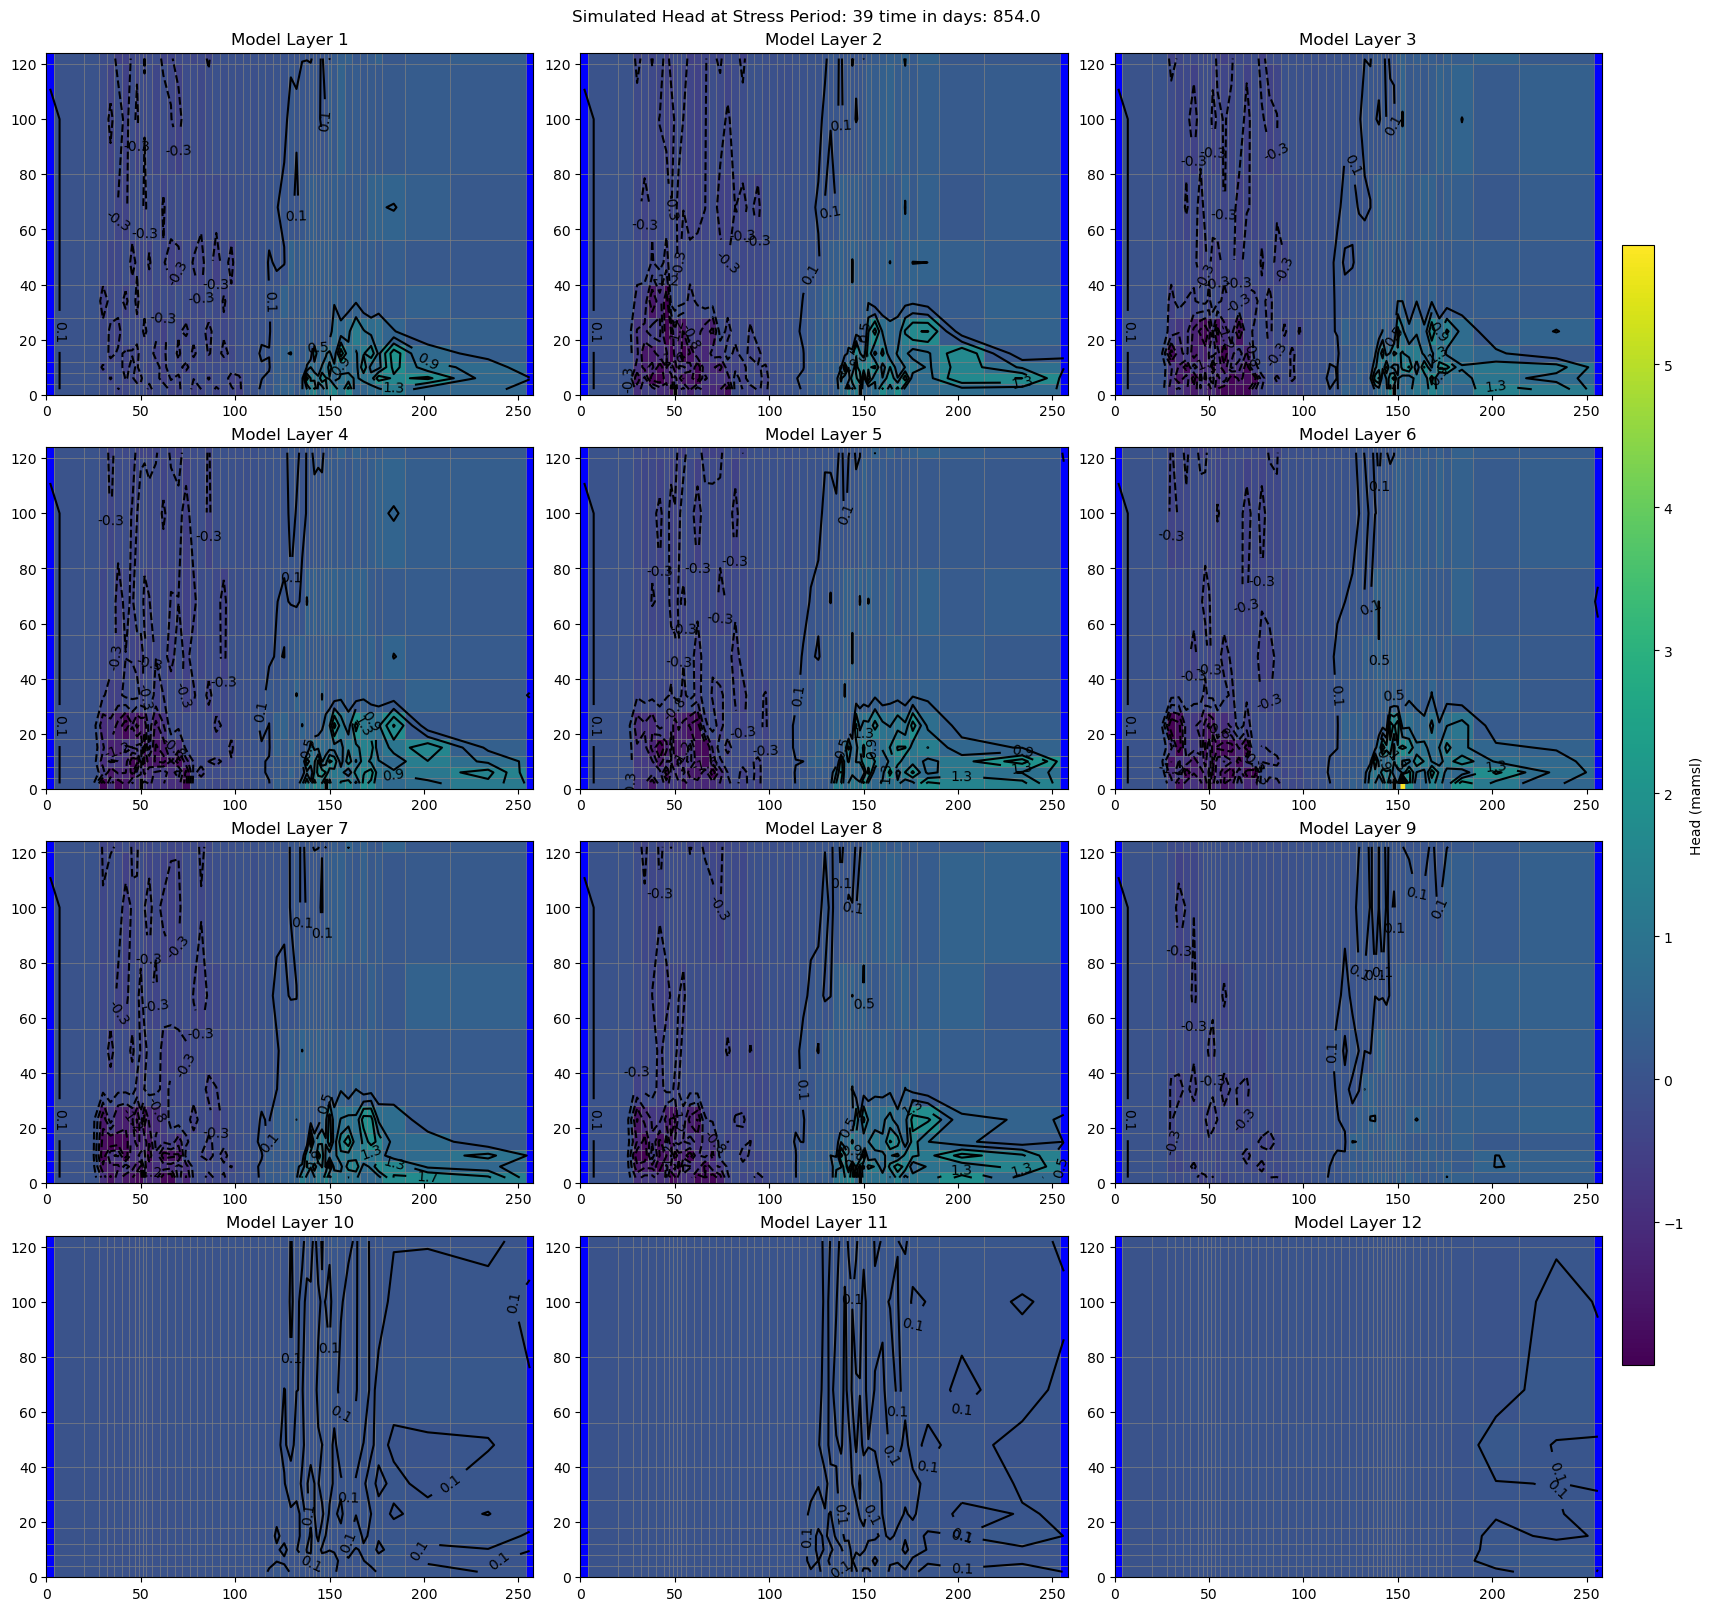

In [110]:
# plot heads in mapview for each layer
h = gwf.output.head().get_alldata()

# plot the head results mapview
mapview_output_dir = os.path.join(model_ws, 'output', 'mapview')
if not os.path.exists(mapview_output_dir):
    os.makedirs(mapview_output_dir)

mapview_counter = 0
for t in range(nper-1, nper):
    h_t = heads[t, :, :, :]
    masked_h = np.ma.masked_where((h_t < -500) | (h_t > 500), h_t)
    vmin = masked_h.min()
    vmax = masked_h.max()
    vmin, vmax = np.nanmin(masked_h), np.nanmax(masked_h)  # Set colorbar limits

    contour_intervals = np.linspace(vmin, vmax, 20)  # Contour levels

    #contour_intervals = np.arange(vmin, vmax, (vmax-vmin)/10)
    
    # Create a figure with 4 rows and 3 columns
    fig, axes = plt.subplots(4, 3, figsize=(16, 16), constrained_layout=True)
    fig.subplots_adjust(right=0.85)  # Leave space for the colorbar
    
    # Loop over all layers
    for i, ax in enumerate(axes.flat):
        if i < nlay:
            # Plot for layer `i`
            ax.set_title(f"Model Layer {i + 1}")
            modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=i)
    
            # Plot array, boundary conditions, and contours
            pa = modelmap.plot_array(h_t[i, :, :], vmin=vmin, vmax=vmax)
            modelmap.plot_bc("WEL", color='black')
            modelmap.plot_bc("CHD", color='blue')
            modelmap.plot_grid(lw=0.5, color="0.5")
            contours = modelmap.contour_array(
                masked_h[i, :, :],
                levels=contour_intervals,
                colors="black",
            )
            ax.clabel(contours, fmt="%2.1f")
        else:
            # Hide axes for extra subplots
            ax.axis("off")
    
    # Add a single colorbar for the entire figure
    cbar_ax = fig.add_axes([1.01, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(pa, cax=cbar_ax, label="Head (mamsl)")
    plt.suptitle('Simulated Head at Stress Period: ' + str(t+1) + ' time in days: ' + str(end_of_stress_period_times[t]))
    # Use tight_layout for clean subplot spacing
    #fig.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to leave space for the colorbar
    # fig.savefig(os.path.join(os.getcwd(), mapview_output_dir, '000' + str(mapview_counter) + '_SimulatedHeads_mamsl_nper_' + str(t+1) + '_time_days_' + str(end_of_stress_period_times[t]) + '.png'), dpi=400, bbox_inches='tight')
    #plt.close(fig)
    mapview_counter+=1
    plt.show()

In [18]:
# start the transort model piece
#add mf6rtm path to the system
import numpy as np
import os
import flopy
from mf6rtm import utils, mf6rtm, mup3d
import re
import difflib
import phreeqcrm

from phreeqcrm import PhreeqcRM

# specify locations of items
#prefix = 'ex5'
#DT_FMT = "%Y-%m-%d %H:%M:%S"
#dataws = os.path.join("data")
#databasews = os.path.join("database")



In [ ]:
# transport model parameters
ne = 0.35 # effective porosity (-) constant across all layers
long_disp = 0.01 # Longitudinal dispersivity (m)constant across all layers
disp_tr_vert = long_disp*0.01 # Transverse vertical dispersivity (m) constant across all layers
disp_tr_hor = long_disp*0.1 # Transverse horizontal dispersivity (m) constant across all layers
diffc = 0 # diffusion coefficient constant across all layers
pbulk = 1850 # bulk density in constant across all layers (m/L^3)

transport_parameters = {

    'ne':           [ne, ne, ne, ne, ne, ne,
                     ne, ne, ne, ne, ne, ne],
    'long_disp':    [long_disp, long_disp, long_disp, long_disp, long_disp, long_disp,
                     long_disp, long_disp, long_disp, long_disp, long_disp, long_disp],
    'disp_tr_vert': [disp_tr_vert, disp_tr_vert, disp_tr_vert, disp_tr_vert, disp_tr_vert, disp_tr_vert, 
                     disp_tr_vert, disp_tr_vert, disp_tr_vert, disp_tr_vert, disp_tr_vert, disp_tr_vert],
    'disp_tr_hor':  [disp_tr_hor, disp_tr_hor, disp_tr_hor, disp_tr_hor, disp_tr_hor, disp_tr_hor, 
                     disp_tr_hor, disp_tr_hor, disp_tr_hor, disp_tr_hor, disp_tr_hor, disp_tr_hor],
    'diffc':        [diffc, diffc, diffc, diffc, diffc, diffc, 
                     diffc, diffc, diffc, diffc, diffc, diffc],
    'pbulk':        [pbulk, pbulk, pbulk, pbulk, pbulk, pbulk, 
                     pbulk, pbulk, pbulk, pbulk, pbulk, pbulk]
}

lin_sorp_distr_coeff = {

    'Orgc':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'O(0)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'C(4)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'C(-4)':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Ca':           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Cl':           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 
    'Fe(2)':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Fe(3)':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'K':            [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Mg':           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'N(3)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'N(5)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Na':           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'S(-2)':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'S(6)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Si':           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Amm':          [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'N(0)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Tmp':          [2.1141E-04, 2.1141E-04, 2.1141E-04, 2.1141E-04, 2.1141E-04, 2.1141E-04,
                     2.1141E-04, 2.1141E-04, 2.1141E-04, 2.1141E-04, 2.1141E-04, 2.1141E-04],
    'pH':           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'pe':           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Ferrihydrite': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Orgmatter':    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Ca_ex':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Fe_ex':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'K_ex':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Mg_ex':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Na_ex':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Pyrite':       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],

}

# define initial concentration conditions in all 12 layers
initial_concentrations = {

    'Orgc':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'O(0)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'C(4)':         [0.008446, 0.008446, 0.008446, 0.008446, 0.008446, 0.008446, 
                     0.008446, 0.008446, 0.008446, 0.008446, 0.008446, 0.008446],
    'C(-4)':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Ca':           [0.002057, 0.002057, 0.002057, 0.002057, 0.002057, 0.002057, 
                     0.002057, 0.002057, 0.002057, 0.002057, 0.002057, 0.002057],
    'Cl':           [0.000254, 0.000254, 0.000254, 0.000254, 0.000254, 0.000254, 
                     0.000254, 0.000254, 0.000254, 0.000254, 0.000254, 0.000254], 
    'Fe(2)':        [0.0001041, 0.0001041, 0.0001041, 0.0001041, 0.0001041, 0.0001041, 
                     0.0001041, 0.0001041, 0.0001041, 0.0001041, 0.0001041, 0.0001041],
    'Fe(3)':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'K':            [0.0001336, 0.0001336, 0.0001336, 0.0001336, 0.0001336, 0.0001336,
                     0.0001336, 0.0001336, 0.0001336, 0.0001336, 0.0001336, 0.0001336],
    'Mg':           [0.0005875, 0.0005875, 0.0005875, 0.0005875, 0.0005875, 0.0005875, 
                     0.0005875, 0.0005875, 0.0005875, 0.0005875, 0.0005875, 0.0005875],
    'N(3)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'N(5)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Na':           [0.0006748, 0.0006748, 0.0006748, 0.0006748, 0.0006748, 0.0006748, 
                     0.0006748, 0.0006748, 0.0006748, 0.0006748, 0.0006748, 0.0006748],
    'S(-2)':        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'S(6)':         [5.516E-05, 5.516E-05, 5.516E-05, 5.516E-05, 5.516E-05, 5.516E-05,
                     5.516E-05, 5.516E-05, 5.516E-05, 5.516E-05, 5.516E-05, 5.516E-05],
    'Si':           [0.0003497, 0.0003497, 0.0003497, 0.0003497, 0.0003497, 0.0003497, 
                     0.0003497, 0.0003497, 0.0003497, 0.0003497, 0.0003497, 0.0003497],
    'Amm':          [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'N(0)':         [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Tmp':          [0.017, 0.017, 0.017, 0.017, 0.017, 0.017, 
                     0.017, 0.017, 0.017, 0.017, 0.017, 0.017],
    'pH':           [6.601, 6.601, 6.601, 6.601, 6.601, 6.601, 
                     6.601, 6.601, 6.601, 6.601, 6.601, 6.681],
    'pe':           [-2.449, -2.449, -2.449, -2.449, -2.449, -2.449, 
                     -2.449, -2.449, -2.449, -2.449, -2.449, -2.449],
    'Ferrihydrite': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
                     0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'Orgmatter':    [2.410781, 0.3873438, 1.445313, 0.1907813, 0.1907813, 0.1907813,
                     1.925156, 1.925156, 1.925156, 1.925156, 1.925156, 1.925156],
    'Ca_ex':        [0.1188, 0.02138, 0.07358, 0.01891, 0.01891, 0.01891,
                     0.05919, 0.05919, 0.05919, 0.05919, 0.05919, 0.05919],
    'Fe_ex':        [0.002451, 0.0004411, 0.001518, 0.0003902, 0.0003902, 0.0003902,
                     0.001221, 0.001221, 0.001221, 0.001221, 0.001221, 0.001221],
    'K_ex':         [0.00157, 0.0002825, 0.0009723, 0.0002499, 0.0002499, 0.0002499, 
                     0.0007822, 0.0007822, 0.0007822, 0.0007822, 0.0007822, 0.0007822],
    'Mg_ex':        [0.02131, 0.003835, 0.0132, 0.003393, 0.003393, 0.003393, 
                     0.01062, 0.01062, 0.01062, 0.01062, 0.01062, 0.01062],
    'Na_ex':        [0.001596, 0.0002872, 0.0009888, 0.0002541, 0.0002541, 0.0002541,
                     0.0007954, 0.0007954, 0.0007954, 0.0007954, 0.0007954, 0.0007954],
    'Pyrite':       [0.0629, 0.0222, 0.0999, 0.01295, 0.01295, 0.01295, 
                     0.13135, 0.13135, 0.13135, 0.13135, 0.13135, 0.13135]
    
}

# define icbund arrays for each layer for the transport model from the previous pht3d model
layer_txt_files = ['layer_1.txt', 'layer_2.txt', 'layer_3.txt', 'layer_4.txt', 
                   'layer_5.txt', 'layer_6.txt', 'layer_7.txt', 'layer_8.txt', 
                   'layer_9.txt', 'layer_10.txt', 'layer_11.txt', 'layer_12.txt']

transport_ws = os.path.join(os.getcwd(), 'transport')

pht3d_icbund = np.zeros((nlay, nrow, ncol))
for i, layer_txt_files in enumerate(layer_txt_files):
    pht3d_icbund[i] = reformat_arrays(os.path.join(transport_ws, 'props', 'icbund', layer_txt_files), 
                                os.path.join(transport_ws, 'props', 'icbund', 'format_'+str(layer_txt_files)), 
                                nrow, 
                                ncol)
    

# define parameters for source-sink-mixing (SSM) package defined from SSM package file
# specify six booleans in line 1 for types
FWEL = 'T' # fwel flag is true
FDRN = 'F' # fdrn flag is false
FRCH = 'F' # frch flag is false
FEVT = 'F' # fevt flag is false
FRIV = 'F' # friv flag is false
FGHB = 'F' # fghb flag is false

ssm_line_1 = pd.DataFrame([[str(FWEL), str(FDRN), str(FRCH), str(FEVT), str(FRIV), str(FGHB)]])
ssm_line_1.columns = [0, 1, 2, 3, 4, 5]  # Assuming the first column is the index column

# define ssm line 2
MXSS = 2245 # maximum number of source-sinks defined from SSM package file
ssm_line_2 = pd.DataFrame([[MXSS]], columns=[0])

# define all of the source-sink terms for the well boundary conditions with chemistry for all 29 constituents
# lay, row, col, CSS (0=dummy value per manual), type (2=well), 
# Orgc, O(0), C(4), C(-4), Ca, 
# Cl, Fe(2), Fe(3), K, Mg, 
# N(3), N(5), Na, S(-2), S(6), 
# Si, Amm, N(0), Tmp, pH, 
# pe, Ferrihydrite, Orgmatter, Ca_ex, Fe_ex, 
# K_ex, Mg_ex, Na_ex, Pyrite

# load in csv of ssm entries
ssm_entry_rows = pd.read_csv(os.path.join(os.getcwd(), 'transport', 'ssm', 'ssm_entries.csv'), index_col=False)
# Remove column headers from the CSV data
ssm_entry_rows.columns = range(ssm_entry_rows.shape[1])  # Reset column names to default integer-based names

# combine all entries to make ssm package dataframe

ssm_combined = pd.concat([ssm_line_1, ssm_line_2, ssm_entry_rows], ignore_index=True, axis=0)

# Check the first 5 columns for numeric values and round them to nearest integer for lay row col css type
# We only modify the first 5 columns (0, 1, 2, 3, 4)
for col in range(5):  # Loop through the first 5 columns
    # Convert values to numeric, keeping 'T' and 'F' booleans intact
    ssm_combined.iloc[1:, col] = pd.to_numeric(ssm_combined.iloc[1:, col], errors='coerce')

    # Round numeric values to nearest whole number (integer), but leave 'T' and 'F' unaffected
    ssm_combined.iloc[1:, col] = ssm_combined.iloc[1:, col].round()

# print combined ssm 
print(ssm_combined)
# Now let's write the DataFrame to a text file while skipping NaN values
file_path = os.path.join(os.getcwd(), 'transport', 'ssm', 'ssm_pkg_test.txt')  # Specify your file path
# Convert DataFrame to string (without NaN values)
ssm_combined_cleaned = ssm_combined.fillna('')  # Replace NaN with empty string if needed
output_str = ssm_combined_cleaned.to_string(index=False, header=False)

# Write the string to a text file
with open(file_path, 'w') as file:
    file.write(output_str)



# import phinp.dat from pht3d model using phreeqc rm
nxyz = nlay * ncol * nrow
nthreads = 3

phreeqc_rm = phreeqcrm.PhreeqcRM(nxyz, nthreads)

database_fpth = os.path.join(os.getcwd(), 'transport', 'database', 'dizon.pht3d_database')

# Load the database
phreeqc_rm.LoadDatabase(database_fpth)

pqi_fpth = os.path.join(os.getcwd(), 'transport', 'pqi', 'phinp.dat')

# Run the input file
phreeqc_rm.RunFile(True, True, True, pqi_fpth)

       0     1     2    3    4       5         6        7    8        9   ...  \
0       T     F     F    F    F       F       NaN      NaN  NaN      NaN  ...   
1    2245   NaN   NaN  NaN  NaN     NaN       NaN      NaN  NaN      NaN  ...   
2       5   NaN   NaN  NaN  NaN     NaN       NaN      NaN  NaN      NaN  ...   
3       2  10.0  39.0  0.0  2.0  0.0001  0.000519  0.00228  0.0  0.00177  ...   
4       3  10.0  39.0  0.0  2.0  0.0001  0.000519  0.00228  0.0  0.00177  ...   
..    ...   ...   ...  ...  ...     ...       ...      ...  ...      ...  ...   
231     2  10.0  39.0  0.0  2.0  0.0001  0.000681  0.00167  0.0  0.00120  ...   
232     3  10.0  39.0  0.0  2.0  0.0001  0.000681  0.00167  0.0  0.00120  ...   
233     4  10.0  39.0  0.0  2.0  0.0001  0.000681  0.00167  0.0  0.00120  ...   
234     6  10.0  39.0  0.0  2.0  0.0001  0.000681  0.00167  0.0  0.00120  ...   
235     8  10.0  39.0  0.0  2.0  0.0001  0.000681  0.00167  0.0  0.00120  ...   

      24   25   26   27   2

0